In [1]:
from statsbombpy import sb

df = sb.events(match_id=3906390)

c:\Users\migue\anaconda3\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [2]:
df.columns

Index(['50_50', 'ball_receipt_outcome', 'ball_recovery_offensive',
       'ball_recovery_recovery_failure', 'block_deflection',
       'carry_end_location', 'clearance_aerial_won', 'clearance_body_part',
       'clearance_head', 'clearance_left_foot', 'clearance_other',
       'clearance_right_foot', 'counterpress', 'dribble_nutmeg',
       'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type',
       'duration', 'foul_committed_advantage', 'foul_committed_card',
       'foul_committed_penalty', 'foul_committed_type', 'foul_won_advantage',
       'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location',
       'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique',
       'goalkeeper_type', 'id', 'index', 'interception_outcome', 'location',
       'match_id', 'minute', 'miscontrol_aerial_won', 'off_camera', 'out',
       'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id',
       'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_deflect

In [ ]:
df = df[['team', 'type', 'player', 'location', 'pass_end_location']]

# Filter down to just passes
df = df[df['type'] == 'Pass']

df.head()

,team,type,player,location,pass_end_location
6,England Women's,Pass,Ella Toone,"[61.0, 40.1]","[51.1, 38.2]"
7,England Women's,Pass,Keira Walsh,"[51.1, 38.0]","[27.8, 47.3]"
8,England Women's,Pass,Millie Bright,"[27.8, 47.4]","[29.5, 62.7]"
9,England Women's,Pass,Jessica Carter,"[44.7, 74.4]","[89.1, 70.2]"
10,Spain Women's,Pass,Olga Carmona García,"[31.0, 9.9]","[40.3, 8.4]"


In [ ]:
df['x'] = df['location'].apply(lambda x: x[0])
df['y'] = df['location'].apply(lambda x: x[1])

df['end_x'] = df['pass_end_location'].apply(lambda x: x[0] if x is not None else None)
df['end_y'] = df['pass_end_location'].apply(lambda x: x[1] if x is not None else None)

df.head()

,team,type,player,location,pass_end_location,x,y,end_x,end_y
6,England Women's,Pass,Ella Toone,"[61.0, 40.1]","[51.1, 38.2]",61.0,40.1,51.1,38.2
7,England Women's,Pass,Keira Walsh,"[51.1, 38.0]","[27.8, 47.3]",51.1,38.0,27.8,47.3
8,England Women's,Pass,Millie Bright,"[27.8, 47.4]","[29.5, 62.7]",27.8,47.4,29.5,62.7
9,England Women's,Pass,Jessica Carter,"[44.7, 74.4]","[89.1, 70.2]",44.7,74.4,89.1,70.2
10,Spain Women's,Pass,Olga Carmona García,"[31.0, 9.9]","[40.3, 8.4]",31.0,9.9,40.3,8.4


In [5]:
from sklearn.cluster import KMeans

df = df.dropna(subset=['end_x', 'end_y'])

df1 = df[df['team'] == 'England Women\'s'].copy()
df2 = df[df['team'] == 'Spain Women\'s'].copy()


X = df1[['x', 'y', 'end_x', 'end_y']]
kmeans = KMeans(n_clusters=5)
df1['cluster'] = kmeans.fit_predict(X)

X = df2[['x', 'y', 'end_x', 'end_y']]
kmeans = KMeans(n_clusters=5)
df2['cluster'] = kmeans.fit_predict(X)

df2.head()

c:\Users\migue\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\migue\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\migue\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\migue\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^

,team,type,player,location,pass_end_location,x,y,end_x,end_y,cluster
10,Spain Women's,Pass,Olga Carmona García,"[31.0, 9.9]","[40.3, 8.4]",31.0,9.9,40.3,8.4,1
11,Spain Women's,Pass,Teresa Abelleira Dueñas,"[42.5, 7.2]","[43.9, 9.1]",42.5,7.2,43.9,9.1,1
13,Spain Women's,Pass,Olga Carmona García,"[68.8, 0.1]","[77.1, 2.8]",68.8,0.1,77.1,2.8,2
14,Spain Women's,Pass,Jennifer Hermoso Fuentes,"[74.6, 3.5]","[68.8, 3.2]",74.6,3.5,68.8,3.2,2
28,Spain Women's,Pass,Catalina Thomas Coll Lluch,"[7.9, 36.9]","[12.1, 55.4]",7.9,36.9,12.1,55.4,4


In [6]:
print(df1['cluster'].value_counts())
print(df2['cluster'].value_counts())

cluster
1    116
2     98
0     71
4     63
3     60
Name: count, dtype: int64
cluster
1    149
2    139
4     83
0     79
3     69
Name: count, dtype: int64


In [7]:
df1 = df1[df1['cluster'].isin(df1['cluster'].value_counts().head(2).index)]
df2 = df2[df2['cluster'].isin(df2['cluster'].value_counts().head(2).index)]

In [8]:
df1.cluster.value_counts()

cluster
1    116
2     98
Name: count, dtype: int64

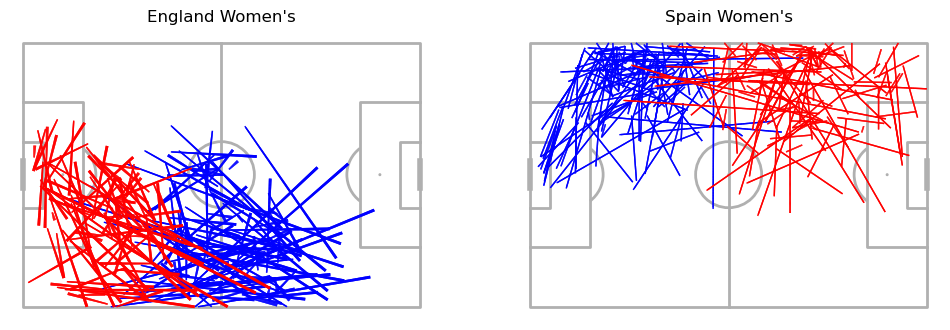

In [9]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

pitch = Pitch(pitch_type='statsbomb')

colors = ['blue', 'red']

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title('England Women\'s')
pitch.draw(ax=ax1)

for i, cluster in enumerate(df1['cluster'].unique()):
    pitch.lines(
        df1[df1['cluster'] == cluster]['x'], 
        df1[df1['cluster'] == cluster]['y'],
        df1[df1['cluster'] == cluster]['end_x'], 
        df1[df1['cluster'] == cluster]['end_y'],
        lw=2,
        comet=True, 
        color=colors[i], 
        ax=ax1
    )
    
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title('Spain Women\'s')
pitch.draw(ax=ax2)

for i, cluster in enumerate(df2['cluster'].unique()):
    pitch.lines(
        df2[df2['cluster'] == cluster]['x'], 
        df2[df2['cluster'] == cluster]['y'],
        df2[df2['cluster'] == cluster]['end_x'], 
        df2[df2['cluster'] == cluster]['end_y'],
        lw=1,
        comet=True, 
        color=colors[i], 
        ax=ax2
    )